In [1]:
!pip install evaluate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import evaluate
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00


## Load English Dataset

In [2]:
print("Loading English dataset...")
english_ds = load_dataset("dair-ai/emotion", "split")

# Map to 3-class sentiment (0=Negative, 1=Neutral, 2=Positive)
def map_emotion(example):
    if example['label'] in [0, 3, 4]:      # sadness, anger, fear
        example['label'] = 0
    elif example['label'] in [1, 2]:       # joy, love
        example['label'] = 2
    else:                                  # surprise
        example['label'] = 1
    return example

english_ds = english_ds.map(map_emotion)

Loading English dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## Load Krio Dataset

In [4]:

# Load annotated file
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("krio_annotation.csv", encoding='latin1', sep='\t')

# Drop rows without label
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)

print(f"Total labeled examples: {len(df)}")
print("Label distribution:")
print(df['label'].value_counts())

Saving krio_annotation.csv to krio_annotation (1).csv
Total labeled examples: 200
Label distribution:
label
1    116
0     45
2     39
Name: count, dtype: int64


## Krio Dataset EDA

Krio Dataset EDA
Total labeled sentences: 200


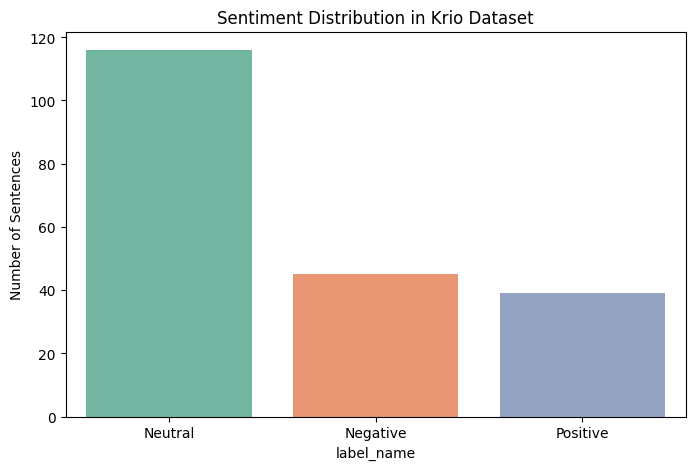


Label Distribution:
label_name
Neutral     116
Negative     45
Positive     39
Name: count, dtype: int64


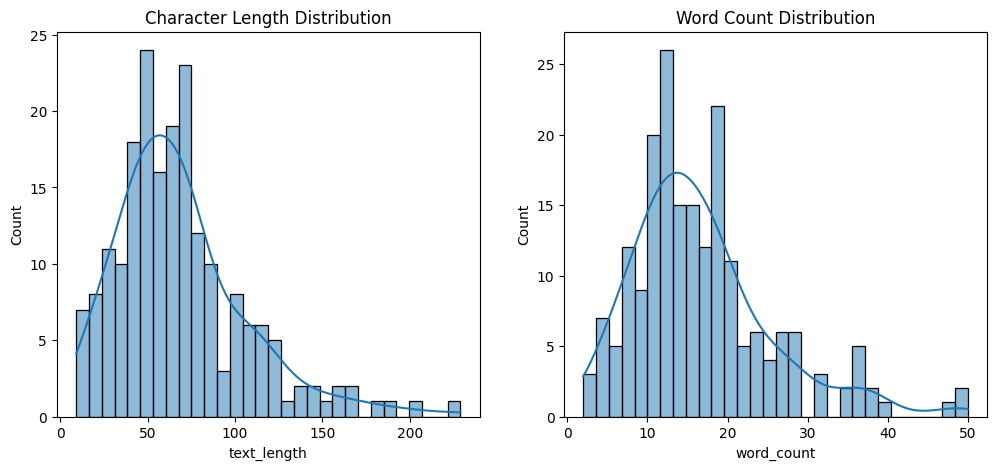


Average words per sentence: 16.7
Max words: 50
EXAMPLE SENTENCES PER CLASS
------------------------------------------------------------

Negative Examples:
- As i es am op so we i wan chap Bindu nain di b?b? ala wai wai mi kr?kr?, mi kr?kr?, mi kr?kr? de krach mi...
- I de naknak di flai f? si se i d?n dai...
- L?do udat g?t dis nek?d gbaga ya we wan gi p?sin tr?bul dis m?nin so!
Di drayva kam d?? di van, j?s es di pikinwit in wan an, put am na di van ?n k?r...
- ?n t?l am n? f? de mek maynd pan d?n kayn pipul de we g?t badat so...
- Na so s?m di trit ful wit wata bik?s di g?ta d?n ?l d?n ful pim...

Neutral Examples:
- Di tru tin na we di k?mi?l in skin klia l?k glas...
- I wach Mista Kotbe we i bin de slip ?n w?nda wetin du i n? pul di dak glasis ?l da t?m de...
- Ticha dr?b Sami f? go om ?n kam skul wit in papa di ?da wik Fraide...
- Na M?ksiko, Gris, Ijipt ?n Itali, faya kin de b?n ?lt?m na di say we pipul d?n de pre...
- As i de rid na so i de rait...

Positive Examples:
- Dat

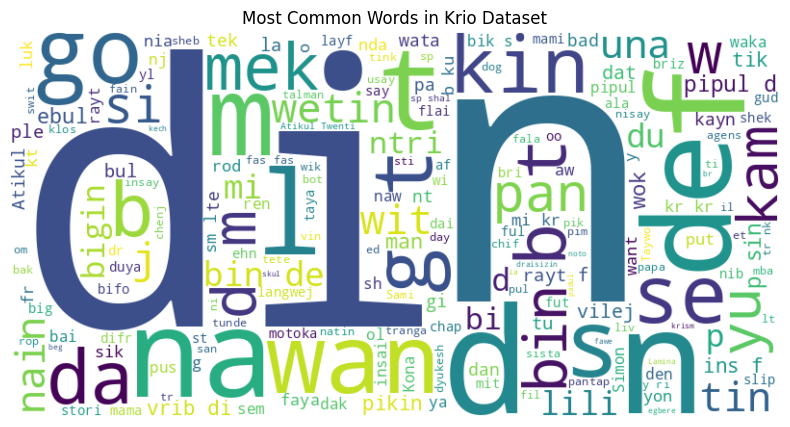

In [7]:
print("Krio Dataset EDA")

# Define label_map
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

df_krio = df.copy()

# Map numerical labels to descriptive names for plotting
df_krio['label_name'] = df_krio['label'].map(label_map)

print(f"Total labeled sentences: {len(df_krio)}")

# Label Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df_krio, x='label_name', hue='label_name', palette='Set2', legend=False)
plt.title('Sentiment Distribution in Krio Dataset')
plt.ylabel('Number of Sentences')
plt.show()

print("\nLabel Distribution:")
print(df_krio['label_name'].value_counts())

# Text Length Analysis
df_krio['text_length'] = df_krio['text_krio'].astype(str).apply(len)
df_krio['word_count'] = df_krio['text_krio'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_krio['text_length'], bins=30, kde=True)
plt.title('Character Length Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_krio['word_count'], bins=30, kde=True)
plt.title('Word Count Distribution')
plt.show()

print(f"\nAverage words per sentence: {df_krio['word_count'].mean():.1f}")
print(f"Max words: {df_krio['word_count'].max()}")

# Examples per Class
print("EXAMPLE SENTENCES PER CLASS")
print("-"*60)

for label in [0,1,2]:
    print(f"\n{label_map[label]} Examples:")
    samples = df_krio[df_krio['label'] == label].sample(min(5, len(df_krio[df_krio['label']==label])))
    for i, row in samples.iterrows():
        print(f"- {row['text_krio'][:150]}...")

# Most Common Words
from wordcloud import WordCloud

all_text = " ".join(df_krio['text_krio'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Krio Dataset')
plt.show()

## Spliting Dataset

In [8]:
# Split: 50 for few-shot + rest for test
few_shot_df, test_df = train_test_split(df, test_size=0.75, random_state=42, stratify=df['label'])

print(f"\nFew-shot train size: {len(few_shot_df)}")
print(f"Test size: {len(test_df)}")

# Convert to Hugging Face Dataset
few_shot_ds = Dataset.from_pandas(few_shot_df)
test_ds = Dataset.from_pandas(test_df)


Few-shot train size: 50
Test size: 150


## Training Baseline- TF-IDF + Logistic Regression

In [9]:
print("\nTraining Baseline (TF-IDF + LR)")

# Use English data for training
english_train = english_ds['train'].to_pandas().sample(4000, random_state=42)

vectorizer = TfidfVectorizer(max_features=8000, stop_words='english')
X_train = vectorizer.fit_transform(english_train['text'])
y_train = english_train['label']

baseline_model = LogisticRegression(max_iter=300, multi_class='multinomial')
baseline_model.fit(X_train, y_train)

# Evaluate on Krio
X_test = vectorizer.transform(test_df['text_krio'])
y_pred = baseline_model.predict(X_test)
y_true = test_df['label']

print("\nBASELINE RESULTS (TF-IDF + Logistic Regression)")
print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print(classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


Training Baseline (TF-IDF + LR)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



BASELINE RESULTS (TF-IDF + Logistic Regression)
Accuracy: 0.22
              precision    recall  f1-score   support

    Negative       0.22      0.88      0.36        34
     Neutral       0.00      0.00      0.00        87
    Positive       0.19      0.10      0.13        29

    accuracy                           0.22       150
   macro avg       0.14      0.33      0.16       150
weighted avg       0.09      0.22      0.11       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Training mBERT and XLM-R

In [10]:
#Tokenize Data
def tokenize_function(examples, tokenizer):
    return tokenizer(examples['text_krio'],
                     padding="max_length",
                     truncation=True,
                     max_length=128)

print("Tokenizing datasets...")

few_shot_tokenized = {}
test_tokenized = {}

Tokenizing datasets...


In [12]:
# Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

# Flexible tokenize function
def tokenize_function(examples, tokenizer):
    # Handle both English ('text') and Krio ('text_krio')
    text_key = 'text_krio' if 'text_krio' in examples else 'text'
    return tokenizer(examples[text_key], padding="max_length", truncation=True, max_length=128)


## Experiments


In [14]:
results = {}

models = {
    "mBERT": "bert-base-multilingual-cased",
    "XLM-R": "xlm-roberta-base"
}

shot_sizes = [0, 10, 50]   # 0 = Zero-shot

for model_name, model_id in models.items():
    print(f"\n{'-'*80}")
    print(f" {model_name} ({model_id})")
    print(f"{'-'*80}")

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    # Tokenize Krio data
    few_shot_tokenized = few_shot_ds.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    test_tokenized = test_ds.map(lambda x: tokenize_function(x, tokenizer), batched=True)

    for shots in shot_sizes:
        exp_name = f"{model_name}_{shots}shot"
        print(f"\n→ Running {shots}-shot experiment...")

        model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=3)

        training_args = TrainingArguments(
            output_dir=f"./results_{exp_name}",
            eval_strategy="no",
            save_strategy="no",
            learning_rate=2e-5,
            per_device_train_batch_size=8,
            num_train_epochs=3,
            weight_decay=0.01,
            report_to="none",
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            eval_dataset=test_tokenized,
            compute_metrics=compute_metrics,
        )

        if shots == 0:
            # Zero-shot: Train on English only
            small_english = english_ds['train'].shuffle(seed=42).select(range(400))
            train_data = small_english.map(lambda x: tokenize_function(x, tokenizer), batched=True)
        else:
            # Few-shot: Select N Krio examples
            train_data = few_shot_tokenized.shuffle(seed=42).select(range(min(shots, len(few_shot_tokenized))))

        trainer.train_dataset = train_data
        trainer.train()

        eval_results = trainer.evaluate()
        results[exp_name] = eval_results

        print(f"   Accuracy: {eval_results['eval_accuracy']:.4f} | Macro F1: {eval_results['eval_macro_f1']:.4f}")

# Summary Table
print("Final Experiment Results")
print("-"*90)
print(f"{'Experiment':<25} {'Accuracy':<10} {'Macro F1':<10}")
print("-" * 90)

for exp, res in results.items():
    print(f"{exp:<25} {res['eval_accuracy']:<10.4f} {res['eval_macro_f1']:<10.4f}")


--------------------------------------------------------------------------------
 mBERT (bert-base-multilingual-cased)
--------------------------------------------------------------------------------


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]


→ Running 0-shot experiment...


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

   Accuracy: 0.2267 | Macro F1: 0.1232

→ Running 50-shot experiment...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argumen

Step,Training Loss


   Accuracy: 0.5800 | Macro F1: 0.2447
Final Experiment Results
------------------------------------------------------------------------------------------
Experiment                Accuracy   Macro F1  
------------------------------------------------------------------------------------------
mBERT_0shot               0.2000     0.1682    
mBERT_10shot              0.5733     0.2630    
mBERT_50shot              0.5800     0.2447    
XLM-R_0shot               0.1800     0.1690    
XLM-R_10shot              0.2267     0.1232    
XLM-R_50shot              0.5800     0.2447    


## Saving Models


In [15]:
# Save Zero-shot and Few-shot models
for model_name in ["mBERT", "XLM-R"]:
    print(f"Saving {model_name} models...")

    # Save few-shot
    fewshot_path = f"./saved_models/{model_name}_fewshot50"
    trainer.save_model(fewshot_path)           # trainer from last run
    tokenizer.save_pretrained(fewshot_path)

    print(f"   → Saved to {fewshot_path}")

Saving mBERT models...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   → Saved to ./saved_models/mBERT_fewshot50
Saving XLM-R models...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   → Saved to ./saved_models/XLM-R_fewshot50


## Error Analysis

In [17]:
# Choose the best model for analysis
best_model_name = "mBERT"
shots = 50

model_path = f"./saved_models/{best_model_name}_fewshot{shots}"

# Load the trained model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Get predictions on test set
test_tokenized = test_ds.map(
    lambda x: tokenize_function(x, tokenizer), batched=True
)

trainer = Trainer(model=model, args=TrainingArguments(output_dir="./temp", report_to="none"))
predictions = trainer.predict(test_tokenized)

# Get predicted labels
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# Error analysis dataframe
error_df = pd.DataFrame({
    'text_krio': test_df['text_krio'].values,
    'true_label': labels,
    'predicted_label': preds,
    'english_ref': test_df.get('text_english', None)
})

error_df['true_label_name'] = error_df['true_label'].map({0:'Negative', 1:'Neutral', 2:'Positive'})
error_df['pred_label_name'] = error_df['predicted_label'].map({0:'Negative', 1:'Neutral', 2:'Positive'})

# Correctness column
error_df['correct'] = error_df['true_label'] == error_df['predicted_label']

print(f"Total Test Examples: {len(error_df)}")
print(f"Overall Accuracy: {error_df['correct'].mean():.4f}")

# Summary
print("Error Analysis Summary")
print("-"*60)

error_summary = error_df[error_df['correct'] == False].groupby(['true_label_name', 'pred_label_name']).size().unstack(fill_value=0)
print("Confusion Matrix (True → Predicted):")
print(error_summary)

# Misclassified examples
print("\n" + "="*60)
print("MISCLASSIFIED EXAMPLES")
print("="*60)

misclassified = error_df[error_df['correct'] == False].copy()
misclassified = misclassified.sample(min(15, len(misclassified)), random_state=42)

for i, row in misclassified.iterrows():
    print(f"\nText: {row['text_krio'][:200]}...")
    print(f"True: {row['true_label_name']} → Predicted: {row['pred_label_name']}")
    if pd.notna(row.get('english_ref')):
        print(f"English Ref: {row['english_ref'][:150]}...")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Total Test Examples: 150
Overall Accuracy: 0.5800
Error Analysis Summary
------------------------------------------------------------
Confusion Matrix (True → Predicted):
pred_label_name  Neutral
true_label_name         
Negative              34
Positive              29

MISCLASSIFIED EXAMPLES

Text: I f? ebul g?t tin f? it, klos, os, m?r?sin ?n i f? ebul abop se if ti? bad f? am na layf, l?k? i sik, in patna ? pikin sik, i l?f wok, day mit am ? i kam ol tum?s, i go g?t ?p fr?m di g?vam?nt...
True: Positive → Predicted: Neutral
English Ref: Thank you thank you
We are thanking the united nation high comission for human rights who did all this work.
The national commission for democracy and...

Text: If na krenkre ?n ?kr?, d?n go put lubi...
True: Positive → Predicted: Neutral
English Ref: Madam Maria and her family live down our street.
Ah, those Krio people!
Today is Monday, Madam Maria and her family will eat the sause from yesterday....

Text: S?nt?m sik na bad tin, b?t wan ?da tin w

## Confusion Matrix

Confusion Matrix
------------------------------------------------------------


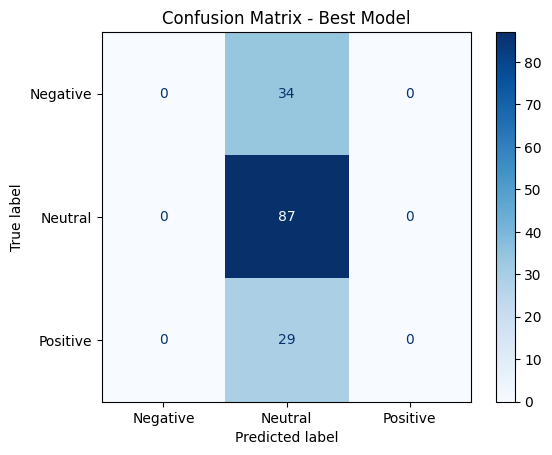

               Pred Negative  Pred Neutral  Pred Positive
True Negative              0            34              0
True Neutral               0            87              0
True Positive              0            29              0


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

print("Confusion Matrix")
print("-"*60)

cm = confusion_matrix(error_df['true_label'], error_df['predicted_label'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Best Model')
plt.show()

# Save confusion matrix as CSV
cm_df = pd.DataFrame(cm,
                     index=['True Negative', 'True Neutral', 'True Positive'],
                     columns=['Pred Negative', 'Pred Neutral', 'Pred Positive'])

# Create the directory if it doesn't exist
output_dir = "./error_analysis"
os.makedirs(output_dir, exist_ok=True)

cm_df.to_csv(os.path.join(output_dir, "confusion_matrix.csv"))
print(cm_df)

## Linguistic error grouping

In [18]:
error_df = error_df.copy()

# Define linguistic feature keywords common in Krio
linguistic_features = {
    'Devil/Danger': ['dɛbul', 'devil', 'kil', 'cutlass', 'trɔbul'],
    'Rash/Pain': ['krɔkrɔ', 'krach', 'rash', 'itch'],
    'Fear/Pleading': ['beg', 'fraɪd', 'sɔri', 'wayooo', 'a beg'],
    'Greed': ['hongri', 'greedy', 'spaida'],
    'Positive Emotion': ['hapi', 'glad', 'bles', 'swit', 'lɛk', 'laf'],
    'Movement/Action': ['padul', 'rɔn', 'go', 'kam'],
    'Story Description': ['stori', 'bin', 'de', 'na']
}

for feature_name, keywords in linguistic_features.items():
    error_df[feature_name] = error_df['text_krio'].astype(str).apply(
        lambda x: any(kw.lower() in x.lower() for kw in keywords)
    )

# Error Rate By Feature
print("Error Rate By Linguistic Feature")
print("-"*70)

feature_analysis = []

for feature in linguistic_features.keys():
    subset = error_df[error_df[feature] == True]
    if len(subset) > 0:
        error_rate = (1 - subset['correct'].mean()) * 100
        feature_analysis.append({
            'Feature': feature,
            'Count': len(subset),
            'Error Rate (%)': round(error_rate, 2),
            'Accuracy (%)': round(subset['correct'].mean() * 100, 2)
        })

feature_df = pd.DataFrame(feature_analysis)
print(feature_df.sort_values('Error Rate (%)', ascending=False))

# Examples of errors per feature

print("Misclassified Examples Per Feature")
print("-"*70)

for feature in linguistic_features.keys():
    misclassified = error_df[(error_df[feature] == True) & (error_df['correct'] == False)]
    if len(misclassified) > 0:
        print(f"\n {feature} ({len(misclassified)} errors):")
        samples = misclassified.sample(min(3, len(misclassified)))
        for i, row in samples.iterrows():
            print(f"   Text: {row['text_krio'][:180]}...")
            print(f"   True: {row['true_label_name']} → Pred: {row['pred_label_name']}")

Error Rate By Linguistic Feature
----------------------------------------------------------------------
             Feature  Count  Error Rate (%)  Accuracy (%)
1          Rash/Pain      1          100.00          0.00
2      Fear/Pleading      3          100.00          0.00
4   Positive Emotion      6           66.67         33.33
5    Movement/Action     46           43.48         56.52
6  Story Description    124           41.94         58.06
0       Devil/Danger      1            0.00        100.00
3              Greed      1            0.00        100.00
Misclassified Examples Per Feature
----------------------------------------------------------------------

 Rash/Pain (1 errors):
   Text: Papa na mi kr?kr? de krach mi, duya a beg di wata we d?n kin tek f? was mi, i de na da ?da vilej yanda, duya una go bri? am kam f? mi...
   True: Negative → Pred: Neutral

 Fear/Pleading (3 errors):
   Text: As i wan chap di sista so nain di b?b? ala, wayooo mi kr?kr? oo mi kr?kr?...
   Tr